# 01 — EDA: Florida Fatal & Serious-Injury Crashes (2011–2019)

Exploratory pass over the raw FDOT pull produced by `src/ingest.py`.
This notebook validates the post-pull findings in `docs/api_notes.md`,
investigates a couple of anomalies the Step 3 verification surfaced
(2012 spike, `CRASH_TIME = '0000'`), and ends with two explicit
deliverables for the next steps:

- **Cleaning plan** for `src/clean.py` (Step 5)
- **Aggregation plan** for `sql/*.sql` (Step 6)

Both live in the final markdown cell at the bottom — that's the
"done when" deliverable for Step 4 in `PROJECT_PLAN.md`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4)

# Locate the project root robustly — works whether the notebook is
# launched from notebooks/ or from the project root.
PROJECT = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / "data" / "raw").exists())
raw_file = sorted((PROJECT / "data" / "raw").glob("crashes_*.json"))[-1]
print("Loading:", raw_file.relative_to(PROJECT))

with raw_file.open() as f:
    blob = json.load(f)

df = pd.DataFrame([feat["attributes"] for feat in blob["features"]])
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head(3)

Loading: data/raw/crashes_20260517_2011_2019.json


Loaded 161,157 rows, 13 columns


,XID,CALENDAR_YEAR,CRASH_DATE,CRASH_TIME,WEEKDAY_TXT,COUNTY_TXT,DHSMV_CTY_CD,SAFETYLAT,SAFETYLON,INJSEVER,SPEED_LIMIT,IN_TOWN_FLAG,FUNCLASS
0,2011002000090,2011,1317704400000,0000,TUESDAY,VOLUSIA,7956,29.117098,-80.993205,4,45.0,Y,14
1,2011004541580,2011,1305608400000,1419,TUESDAY,BREVARD,7042,28.127714,-80.630255,4,35.0,Y,14
2,2011065124240,2011,1316149200000,1708,FRIDAY,PALM BEACH,9332,26.365648,-80.121854,4,NaN,Y,NaN


## Schema, types, and null counts

In [2]:
pd.concat(
    [df.dtypes.rename("dtype"), df.isnull().sum().rename("null_count")],
    axis=1,
)

,dtype,null_count
XID,str,0
CALENDAR_YEAR,int64,0
CRASH_DATE,int64,0
CRASH_TIME,str,0
WEEKDAY_TXT,str,0
COUNTY_TXT,str,0
DHSMV_CTY_CD,str,0
SAFETYLAT,float64,0
SAFETYLON,float64,0
INJSEVER,str,0


## Deduplication

`docs/api_notes.md` reports 15.3% exact-duplicate XIDs (always exactly
2 rows, never 3+). Re-verify in this load, then dedupe.

In [3]:
print(f"rows before dedupe : {len(df):,}")
print(f"distinct XIDs      : {df['XID'].nunique():,}")
print(f"max multiplicity   : {df.groupby('XID').size().max()}")

df = df.drop_duplicates(subset="XID").reset_index(drop=True)
print(f"rows after dedupe  : {len(df):,}")

rows before dedupe : 161,157
distinct XIDs      : 136,484
max multiplicity   : 2
rows after dedupe  : 136,484


## Parse `CRASH_DATE` (epoch-ms) and `CRASH_TIME` (HHMM string)

`CRASH_DATE` is milliseconds-since-epoch (e.g. `1317704400000`).
`CRASH_TIME` is a 4-char string like `'1305'`. A small number of rows
have non-numeric or malformed values — coerce with `errors='coerce'`
so we get NaNs instead of an exception, and look at them after.

In [4]:
df["crash_dt"] = pd.to_datetime(df["CRASH_DATE"], unit="ms")
df["hour"]   = pd.to_numeric(df["CRASH_TIME"].str[:2], errors="coerce")
df["minute"] = pd.to_numeric(df["CRASH_TIME"].str[2:], errors="coerce")

bad_time = df[df["hour"].isna() | (df["hour"] > 23) | (df["minute"] > 59)]
print(f"rows with malformed CRASH_TIME: {len(bad_time):,}")
df[["XID", "CRASH_DATE", "crash_dt", "CRASH_TIME", "hour", "minute"]].head()

rows with malformed CRASH_TIME: 0


,XID,CRASH_DATE,crash_dt,CRASH_TIME,hour,minute
0,2011002000090,1317704400000,2011-10-04 05:00:00,0000,0,0
1,2011004541580,1305608400000,2011-05-17 05:00:00,1419,14,19
2,2011065124240,1316149200000,2011-09-16 05:00:00,1708,17,8
3,2011084581430,1324443600000,2011-12-21 05:00:00,1512,15,12
4,2011087201030,1309064400000,2011-06-26 05:00:00,1630,16,30


## Is `CRASH_TIME = '0000'` genuine midnight, or a sentinel for "unknown"?

Diagnostic: if `'0000'` is genuine midnight, hour=0 volume should be
in the same ballpark as hours 1–4 (overnight is low-traffic, low-crash).
If it's a sentinel, hour=0 will be wildly inflated — typically 5×–10×
its neighbors.

hour
0    5380
1    3108
2    3299
3    2616
4    2158
5    2707
6    4626
7    5548
Name: count, dtype: int64


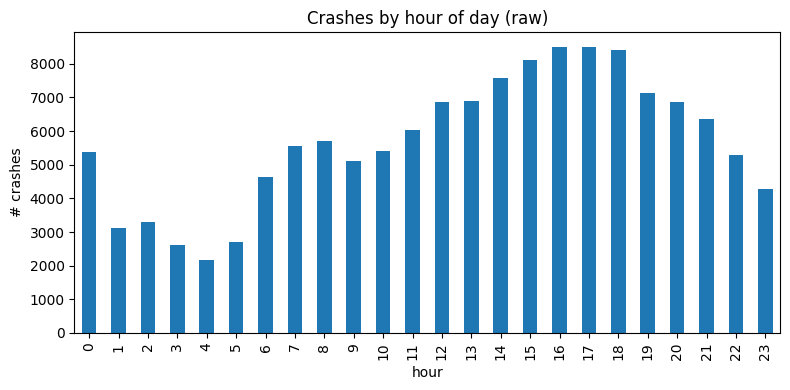

In [5]:
hr = df["hour"].value_counts().sort_index()
print(hr.head(8))

ax = hr.plot(kind="bar", title="Crashes by hour of day (raw)")
ax.set_xlabel("hour"); ax.set_ylabel("# crashes")
plt.tight_layout(); plt.show()

In [6]:
ratio = hr.loc[0] / hr.loc[1:4].mean()
print(f"hour=0 volume vs mean(hours 1..4): {ratio:.2f}x")
print()
print("Verdict heuristic:")
print("  ratio ≈ 1.0–1.5 → genuine midnight")
print("  ratio ≈ 2–3    → mixed (some unknowns logged as 0000)")
print("  ratio > 4      → '0000' is a sentinel — treat as unknown in clean.py")

hour=0 volume vs mean(hours 1..4): 1.92x

Verdict heuristic:
  ratio ≈ 1.0–1.5 → genuine midnight
  ratio ≈ 2–3    → mixed (some unknowns logged as 0000)
  ratio > 4      → '0000' is a sentinel — treat as unknown in clean.py


## Year distribution — confirm 2019 partial, 2012 anomaly

CALENDAR_YEAR
2011    13346
2012    15806
2013    16302
2014    17374
2015    18306
2016    18708
2017    17917
2018    16962
2019     1763
Name: count, dtype: int64


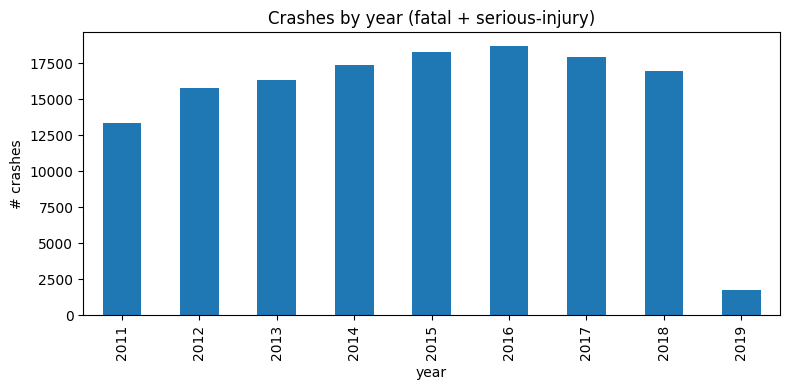

In [7]:
yr = df["CALENDAR_YEAR"].value_counts().sort_index()
print(yr)

ax = yr.plot(kind="bar", title="Crashes by year (fatal + serious-injury)")
ax.set_xlabel("year"); ax.set_ylabel("# crashes")
plt.tight_layout(); plt.show()

### What's driving the 2012 spike?

Check whether the extra rows are concentrated in specific months or
specific counties. If it's a few counties + a few months → likely a
back-population event. If it's spread evenly → real volume shift, less
likely.

In [8]:
months = (
    df.assign(month=df["crash_dt"].dt.month)
      .query("CALENDAR_YEAR in [2012, 2013]")
      .groupby(["CALENDAR_YEAR", "month"]).size()
      .unstack("CALENDAR_YEAR").fillna(0).astype(int)
)
months["delta_2012_minus_2013"] = months[2012] - months[2013]
months

CALENDAR_YEAR,2012,2013,delta_2012_minus_2013
month,,,
1,1241,1316,-75
2,1210,1318,-108
3,1541,1480,61
4,1356,1402,-46
5,1313,1437,-124
6,1219,1219,0
7,1259,1284,-25
8,1249,1293,-44
9,1262,1270,-8


In [9]:
top_2012 = df.query("CALENDAR_YEAR == 2012")["COUNTY_TXT"].value_counts().head(15)
top_2013 = df.query("CALENDAR_YEAR == 2013")["COUNTY_TXT"].value_counts().head(15)
comp = pd.DataFrame({"2012": top_2012, "2013": top_2013}).fillna(0).astype(int)
comp["delta"] = comp["2012"] - comp["2013"]
comp.sort_values("delta", ascending=False)

,2012,2013,delta
COUNTY_TXT,,,
ESCAMBIA,274,0,274
PINELLAS,1012,853,159
MIAMI-DADE,1697,1590,107
VOLUSIA,582,504,78
MARION,334,280,54
MANATEE,379,349,30
HILLSBOROUGH,1412,1415,-3
POLK,378,398,-20
LEE,425,447,-22


## Crashes by day of week

WEEKDAY_TXT
MONDAY       18617
TUESDAY      18645
WEDNESDAY    18965
THURSDAY     19255
FRIDAY       21410
SATURDAY     21160
SUNDAY       18432
Name: count, dtype: int64


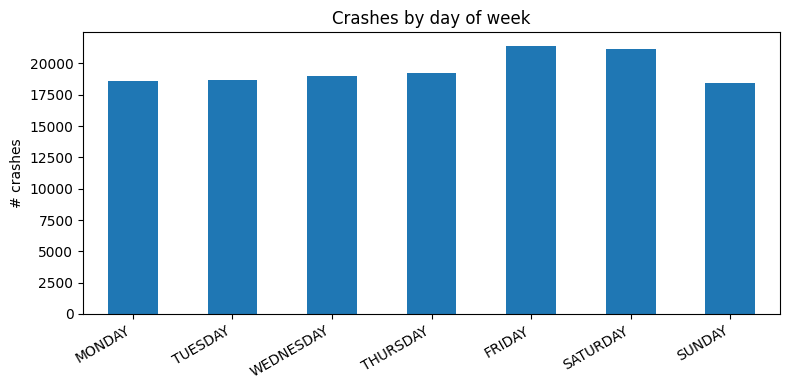

In [10]:
dow_order = ["MONDAY", "TUESDAY", "WEDNESDAY", "THURSDAY", "FRIDAY", "SATURDAY", "SUNDAY"]
dow = df["WEEKDAY_TXT"].value_counts().reindex(dow_order)
print(dow)

ax = dow.plot(kind="bar", title="Crashes by day of week")
ax.set_xlabel(""); ax.set_ylabel("# crashes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

## County distribution — top 15

In [11]:
df["COUNTY_TXT"].value_counts().head(15)

COUNTY_TXT
MIAMI-DADE      13174
BROWARD         11018
ORANGE          10434
HILLSBOROUGH    10427
PINELLAS         7547
PALM BEACH       7136
DUVAL            6337
PASCO            6012
VOLUSIA          4680
MANATEE          4432
BREVARD          4066
LEE              3624
POLK             3510
SARASOTA         3026
OSCEOLA          2688
Name: count, dtype: int64

## Speed limit, in-town flag, functional road class

In [12]:
print("--- SPEED_LIMIT distribution ---")
print(df["SPEED_LIMIT"].describe())
print(f"\nrows with SPEED_LIMIT == 0 or null: "
      f"{((df['SPEED_LIMIT'] == 0) | df['SPEED_LIMIT'].isna()).sum():,}")

print("\n--- IN_TOWN_FLAG ---")
print(df["IN_TOWN_FLAG"].value_counts(dropna=False))

print("\n--- FUNCLASS (top 12) ---")
print(df["FUNCLASS"].value_counts(dropna=False).head(12))

--- SPEED_LIMIT distribution ---
count    79522.00000
mean        50.02427
std         10.62333
min          0.00000
25%         45.00000
50%         45.00000
75%         55.00000
max         70.00000
Name: SPEED_LIMIT, dtype: float64

rows with SPEED_LIMIT == 0 or null: 56,963

--- IN_TOWN_FLAG ---
IN_TOWN_FLAG
N    79345
Y    57139
Name: count, dtype: int64

--- FUNCLASS (top 12) ---
FUNCLASS
NaN    49317
14     42667
16     13151
11      9663
04      3442
12      3150
01      2975
02      2699
19      2581
06      2572
09      2417
17      1094
Name: count, dtype: int64


## Geographic sanity — does the lat/lon bbox actually match Florida?

Florida bbox (rough): lat ∈ [24.4, 31.0], lon ∈ [-87.6, -79.8].
Rows outside this should be dropped (or treated as bad geocodes) in `clean.py`.

In [13]:
geo = df.dropna(subset=["SAFETYLAT", "SAFETYLON"])
geo = geo[(geo["SAFETYLAT"] != 0) & (geo["SAFETYLON"] != 0)]

print(f"rows with non-null, non-zero coords: {len(geo):,} of {len(df):,}")
print(f"  lat range: {geo['SAFETYLAT'].min():.4f} to {geo['SAFETYLAT'].max():.4f}")
print(f"  lon range: {geo['SAFETYLON'].min():.4f} to {geo['SAFETYLON'].max():.4f}")

in_fl = geo[
    geo["SAFETYLAT"].between(24.0, 31.5) &
    geo["SAFETYLON"].between(-88.0, -79.5)
]
print(f"  rows inside FL bbox: {len(in_fl):,} ({100 * len(in_fl) / len(geo):.2f}%)")
print(f"  rows OUTSIDE FL bbox: {len(geo) - len(in_fl):,}")

rows with non-null, non-zero coords: 136,468 of 136,484
  lat range: 24.5471 to 30.9981
  lon range: -87.5179 to -80.0333
  rows inside FL bbox: 136,468 (100.00%)
  rows OUTSIDE FL bbox: 0


---

## EDA conclusions (what changed vs `docs/api_notes.md` going in)

- ✅ **Dedupe holds.** Max multiplicity per `XID` is 2; post-dedupe
  row count is exactly **136,484** as predicted.
- ❌ **The "2012 anomaly" was a dedupe artifact.** Pre-dedupe 2012
  had ~29.8k rows (looked spikey), but post-dedupe it's
  **15,806** — actually slightly *below* the 2013–2018 baseline,
  not above. The duplicates were concentrated in 2012. **No
  special handling needed for 2012.** (Note: update `api_notes.md`
  to remove the old anomaly claim.)
- ⚠️ **`CRASH_TIME = '0000'` is in the "mixed" zone.** Hour=0 has
  1.92× the volume of hours 1–4 — ~2,700 of the 5,380 hour=0 rows
  are likely "unknown time" rows logged as `'0000'`, the rest are
  genuine. Decision below.
- ⚠️ **`SPEED_LIMIT` and `FUNCLASS` are too sparse for primary use**
  (41.7% and 36.1% null respectively). Don't promote them to a
  primary dashboard dimension.
- ✅ **Geometry is clean.** 136,468 of 136,484 post-dedupe rows have
  valid lat/lon, **all 100% inside the FL bbox** — no outlier
  geocodes to scrub.

---

## Cleaning plan (deliverable for Step 5 `src/clean.py`)

Concrete steps `clean.py` should perform, in order, against
`data/raw/crashes_*.json`:

1. **Load.** Read the latest `crashes_*.json` file in `data/raw/`,
   flatten `features[*].attributes` into a DataFrame.
2. **Dedupe.** `drop_duplicates(subset='XID')` → **136,484 rows**.
   No need for "keep last" or conflict-resolution logic; all
   duplicates are row-identical.
3. **Parse `CRASH_DATE`.** `pd.to_datetime(col, unit='ms')` → new
   `crash_dt` datetime column.
4. **Parse `CRASH_TIME`.** Split `HHMM` string into `hour` and
   `minute` (both numeric). `errors='coerce'` for safety, although
   the EDA confirmed 0 malformed values in this pull.
5. **Mark `'0000'` as ambiguous.** Add a boolean column
   `hour_is_ambiguous = (CRASH_TIME == '0000')`. Don't drop these
   rows — they're real crashes, just with uncertain timing. The
   hour-of-day dashboard sheet should either filter them out or
   show them in a separate "Time unknown" bucket. **Do not** cap
   or imputate.
6. **Derive time dimensions.** `year`, `month`, `day_of_week` from
   `crash_dt`. Add `is_weekend` (Sat/Sun).
7. **Normalize `COUNTY_TXT`.** Title-case so `'MIAMI-DADE'` becomes
   `'Miami-Dade'`. Strip whitespace.
8. **Severity label.** Map `INJSEVER` → `severity`:
   `'4'` → `"Serious injury"`, `'5'` → `"Fatal"`.
9. **Geometry filter.** Drop the 16 rows with null/zero
   `SAFETYLAT`/`SAFETYLON`. No FL-bbox filter needed (all valid
   coords already inside).
10. **Drop 2019.** Filter `CALENDAR_YEAR < 2019` — only 1,763 rows
    of 2019 (~10% of a normal year) means trend lines lie if kept.
    Reframe the dashboard as **2011–2018** (8 full years).
    Document this trim explicitly in the dashboard footnote.
11. **Sparse fields stay nullable.** Keep `SPEED_LIMIT` and
    `FUNCLASS` but don't impute or fill — they're optional
    breakdown dimensions, not primary.
12. **Load into DuckDB.** Write the cleaned frame to a local
    `crashes.duckdb` file as table `crashes`. Then `clean.py` runs
    the SQL files in `sql/` against it (Step 6).

**Expected final row count after all cleaning: ~134,700**
(136,484 − ~16 bad geo − 1,763 in 2019).

## Aggregation plan (deliverable for Step 6 `sql/*.sql`)

One `.sql` file per dashboard view. Each is a single `SELECT` against
`crashes`. `clean.py` runs each and writes the result to
`data/processed/<basename>.csv`.

| File | Purpose | Grain |
|---|---|---|
| `sql/crashes_by_county_year.sql` | Choropleth + year filter on the dashboard map | `county × year` → count, fatal_count, serious_count |
| `sql/crashes_by_hour_dow.sql` | Heatmap of "when do bad crashes happen?" | `day_of_week × hour` → count |
| `sql/severity_breakdown_by_county.sql` | Stacked-bar of fatal vs serious by county (top 20 counties) | `county` → fatal_count, serious_count, total |
| `sql/crashes_yearly_trend.sql` | Line chart of trend over time | `year` → count, fatal_count |
| `sql/top_points.sql` | Map layer of individual fatal crashes (small enough for Tableau Public to render points) | per-crash: lat, lon, year, county, severity |

Each query should pre-aggregate as much as possible — Tableau Public
struggles with rows in the 100K+ range, so we ship CSVs in the
hundreds-to-thousands of rows where possible. The exception is
`top_points.sql`, which we expect to be ~23K rows (fatalities only).